In [1]:
%load_ext autoreload

In [ ]:
import anndata as ad 
import bosperrus
from bosperrus.distances import distance_to_pointset
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import scanpy as sc
import seaborn as sns
import squidpy as sq
import sys

In [ ]:
# distance_to_pointset already imported in the cell above

In [4]:
adata = sq.datasets.imc()

In [5]:
def coarse_cell_type(cell_type):
    if cell_type in ["B cells", "T cells", "macrophages", "endothelial"]:
        return "immune"
    elif cell_type in ['apoptotic tumor cell', 'p53+ EGFR+ tumor cell', 'basal CK tumor cell', 'CK low HR low tumor cell', 'CK+ HR+ tumor cell', 'proliferative tumor cell']:
        return "tumor cell"
    elif cell_type in ['vimentin hi stromal cell', 'small elongated stromal cell']:
        return "stromal cell"
    else:
        raise ValueError

adata.obs["coarse cell type"] = adata.obs["cell type"].apply(coarse_cell_type)

/tmp/ipykernel_404890/2606472541.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="coarse cell type", spot_size=10)


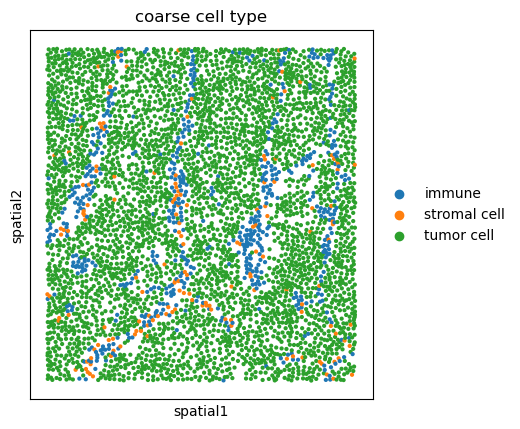

In [6]:
sc.pl.spatial(adata, color="coarse cell type", spot_size=10)

In [7]:
cell_type_key = "coarse cell type"
cell_types = adata.obs[cell_type_key].unique()

In [ ]:
result_dict = dict()
for cell_type in cell_types:
    pointset = adata[adata.obs[cell_type_key] == cell_type].obsm["spatial"].copy()
    coordinates = adata[adata.obs[cell_type_key] != cell_type].obsm["spatial"].copy()
    expression = pd.DataFrame(adata[adata.obs[cell_type_key] != cell_type].X, columns=adata.var_names)
    bf = bosperrus.Flow.from_coords_and_scores(coordinates, distance_fn=distance_to_pointset, scores=expression, distance_kwargs={"pointset": pointset})
    bf.flow()
    result_dict[cell_type] = bf.fit_quality.loc["scaled_relative_likelihood_over_baseline"]

In [13]:
all_results = pd.concat(result_dict, axis=1)

In [14]:
all_results

,tumor cell,immune,stromal cell
1021522Tm169Di EGFR,1.029186,1.042264,1.108024
1031747Er167Di ECadhe,1.09515,1.026267,1.052931
112475Gd156Di Estroge,1.000968,1.015815,1.037877
117792Dy163Di GATA3,1.000917,0.999661,1.001611
1261726In113Di Histone,1.01194,1.024453,1.037893
1441101Er168Di Ki67,1.000526,0.99995,0.999991
174864Nd148Di SMA,1.015573,1.036652,1.024836
1921755Sm149Di Vimenti,1.020716,1.075727,1.058015
198883Yb176Di cleaved,1.001955,1.002509,1.00395
201487Eu151Di cerbB,1.065465,1.023013,1.053677


In [ ]:
all_results.filter(like="scaled_relative_likelihood").idxmax()

In [ ]:
all_results.loc[("stromal cell", 32)].dropna()

In [ ]:
cell_type = "stromal cell"
pointset = adata[adata.obs[cell_type_key] == cell_type].obsm["spatial"].copy()
coordinates = adata[adata.obs[cell_type_key] != cell_type].obsm["spatial"].copy()
expression = pd.DataFrame(adata[adata.obs[cell_type_key] != cell_type].X, columns=adata.var_names)

distances = distance_to_pointset(coordinates, pointset=pointset)
bf = bosperrus.Flow.from_distances_and_scores(distances=distances, scores=expression)
bf.flow(measures=list(adata.var_names))

In [ ]:
d = bf.observations["distance_to_pointset"]
C = bf.observations["phospho mTOR"]

In [ ]:
# Michaelis-Menten functional form: a * d / (b + d) + c
# Parameters come from bf.fit_quality (the best fit for "phospho mTOR")
a = bf.fit_quality.loc["michaelis_menten_a", "phospho mTOR"]
b = bf.fit_quality.loc["michaelis_menten_b", "phospho mTOR"]
c = bf.fit_quality.loc["michaelis_menten_c", "phospho mTOR"]
C_model = a * d / (b + d) + c

In [ ]:
basal_ck_tumor_cells = adata[adata.obs[cell_type_key] == "stromal cell"]
rest = adata[adata.obs[cell_type_key] != "stromal cell"]

In [ ]:
cell_type_codes = rest.obs[cell_type_key].astype("category").cat.codes
colors = adata.uns["cell type_colors"]
cmap = ListedColormap(colors)
plt.scatter(x=d, y=C, c=cell_type_codes, cmap=cmap, s=0.5)
#plt.scatter(x=d, y=C_model, color="red", s=0.5)
plt.xlabel("Distance to basal CK tumor cell")
plt.ylabel("346876Sm147Di Keratin")

In [ ]:
basal_ck_tumor_cells = adata[adata.obs[cell_type_key] == "stromal cell"]
rest = adata[adata.obs[cell_type_key] != "stromal cell"]
plt.scatter(basal_ck_tumor_cells.obsm["spatial"][:,0], basal_ck_tumor_cells.obsm["spatial"][:,1], color="red", s=1, label="stromal cell")
plt.scatter(rest.obsm["spatial"][:,0], rest.obsm["spatial"][:,1], c=rest.X[:, adata.var_names == "phospho mTOR"], s=5, label="phospho mTOR")
plt.axis("square")
plt.legend(loc="lower center")
plt.show()

In [ ]:
influencer = "stromal cell"
pointset = adata[adata.obs[cell_type_key] == influencer].obsm["spatial"].copy()

result_dict = dict()
for other_cell_type in cell_types:
    if other_cell_type == influencer:
        continue
    coordinates = adata[adata.obs[cell_type_key] == other_cell_type].obsm["spatial"].copy()
    expression = pd.DataFrame(adata[adata.obs[cell_type_key] == other_cell_type].X, columns=adata.var_names)

    distances = distance_to_pointset(coordinates, pointset=pointset)
    bf = bosperrus.Flow.from_distances_and_scores(distances=distances, scores=expression)
    bf.flow(measures=list(adata.var_names))
    result_dict[other_cell_type] = bf.fit_quality

In [ ]:
adata.var_names